# Step 1: Import Required Libraries

This step initializes the core libraries required for data validation and inspection.

- pandas: for data manipulation and analysis
- numpy: for numerical operations

This notebook was used for both ETL and EDA processes. 

The sample Cyclic Datasets from 2019-Q1 AND 2020-Q1 were merged.

In [1]:
import pandas as pd
import numpy as np

# Step 2: Load Raw Datasets and Initial Validation

In this step, both Divvy datasets (2019 and 2020) are loaded separately without applying any transformations.

The primary objective is to:
- Inspect the raw structure of each dataset
- Compare dataset sizes
- Identify differences in schema and column definitions
- Detect potential inconsistencies before data processing

This step is critical because merging datasets without validating their structure can lead to data corruption and incorrect analysis.

---

## Dataset Loading

Both datasets were successfully loaded:

- **2019 Dataset Shape:** (365,069 rows, 12 columns)
- **2020 Dataset Shape:** (426,887 rows, 13 columns)

This indicates sufficient data volume for robust analysis.

---

## Column Structure Inspection

A detailed comparison of column names reveals significant schema differences between the two datasets.

### 2019 Dataset Columns:

- trip_id  
- start_time  
- end_time  
- bikeid  
- tripduration  
- from_station_id  
- from_station_name  
- to_station_id  
- to_station_name  
- usertype  
- gender  
- birthyear  

---

### 2020 Dataset Columns:

- ride_id  
- rideable_type  
- started_at  
- ended_at  
- start_station_name  
- start_station_id  
- end_station_name  
- end_station_id  
- start_lat  
- start_lng  
- end_lat  
- end_lng  
- member_casual  

---

## Key Observations

Several important inconsistencies were identified:

1. **Column Naming Differences**
   - start_time vs started_at  
   - end_time vs ended_at  
   - usertype vs member_casual  

2. **Structural Differences**
   - 2019 dataset contains demographic fields (gender, birthyear)
   - 2020 dataset includes geospatial data (latitude and longitude)

3. **Feature Availability**
   - rideable_type is only available in 2020
   - tripduration is only available in 2019

---

## Implication for Data Processing

Due to these inconsistencies, the datasets cannot be merged directly.

A schema alignment step is required to:
- Standardize column names
- Retain only comparable analytical features
- Ensure consistency across all records

---

## Next Step

The next step will focus on **standardizing both datasets to a common schema** before merging.

In [29]:
df_2019 = pd.read_csv("Divvy_Trips_2019_Q1.csv")
df_2020 = pd.read_csv("Divvy_Trips_2020_Q1.csv")

print("2019 Shape:", df_2019.shape)
print("2020 Shape:", df_2020.shape)

2019 Shape: (365069, 12)
2020 Shape: (426887, 13)


In [30]:
df_2019.columns
df_2020.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

In [31]:
print("2019 Columns:\n", df_2019.columns)
print("\n2020 Columns:\n", df_2020.columns)

2019 Columns:
 Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='str')

2020 Columns:
 Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')


# Step 3: Schema Alignment (Critical Step)

The 2019 and 2020 datasets use different schemas.

To ensure compatibility:
- 2019 dataset is transformed to match 2020 structure
- Only common analytical columns are retained

This prevents data corruption during merging.

In [32]:
# Standardize 2019 dataset to match 2020 schema

df_2019_clean = pd.DataFrame({
    'ride_id': df_2019['trip_id'],
    'rideable_type': 'classic_bike',  # Not available in 2019
    'started_at': df_2019['start_time'],
    'ended_at': df_2019['end_time'],
    'start_station_name': df_2019['from_station_name'],
    'start_station_id': df_2019['from_station_id'],
    'end_station_name': df_2019['to_station_name'],
    'end_station_id': df_2019['to_station_id'],
    'start_lat': np.nan,
    'start_lng': np.nan,
    'end_lat': np.nan,
    'end_lng': np.nan,
    'member_casual': df_2019['usertype']
})

# Step 4: Prepare 2020 Dataset

The 2020 dataset already follows the modern schema.

No transformation is required.

In [33]:
df_2020_clean = df_2020.copy()

# Step 5-1: Merge Datasets

After schema alignment, both datasets are merged into a single dataframe.

This ensures consistency across all records.

In [34]:
df = pd.concat([df_2019_clean, df_2020_clean], ignore_index=True)

print("Combined shape:", df.shape)

Combined shape: (791956, 13)


# Step 5-2: Standardizing User Type Classification

The dataset contains two naming conventions for user types:

- 2019: Subscriber, Customer
- 2020: member, casual

These represent the same underlying categories.

To ensure consistency:
- Subscriber → member
- Customer → casual

This standardization is essential for accurate comparative analysis.

In [35]:
#df['member_casual'] = df['member_casual'].replace({
#    'Subscriber': 'member',
#    'Customer': 'casual'
#})
# Standardize user types
df['member_casual'] = df['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

# Verify
print(df['member_casual'].value_counts())

member_casual
member    720313
casual     71643
Name: count, dtype: int64


# Step 6: Datetime Conversion

The 'started_at' and 'ended_at' columns are converted into datetime format.

This step is essential for:
- Calculating ride duration
- Extracting time-based features (hour, day, month)
- Ensuring consistency across datasets

Invalid datetime values are coerced and removed to maintain data integrity.

In [36]:
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')

# Remove invalid datetime rows
df = df.dropna(subset=['started_at', 'ended_at'])

print("After datetime cleaning:", df.shape)

After datetime cleaning: (791956, 13)


# Step 7: Ride Length Calculation

Ride duration is calculated as the difference between 'ended_at' and 'started_at'.

The result is converted into minutes for consistency and analytical usability.

Invalid rides (negative or zero duration) are removed.

In [37]:
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Remove invalid rides
df = df[df['ride_length'] > 0]

print(df['ride_length'].describe())

count    791746.000000
mean         19.735499
std         553.618998
min           0.016667
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64


# Step 8: Outlier Removal

Extreme ride durations were detected (e.g., rides exceeding several days), which are not realistic for bike-share usage.

To ensure analytical accuracy:
- Ride durations greater than 24 hours (1440 minutes) are removed
- This threshold aligns with expected usage behavior

Removing outliers prevents distortion of statistical metrics and improves reliability of insights.

In [38]:
# Remove extreme outliers (> 24 hours)
#df = df[df['ride_length'] < 1440]
df = df[(df['ride_length'] > 1) & (df['ride_length'] < 90)]
print(df['ride_length'].describe())

count    778155.000000
mean         12.161491
std          10.419849
min           1.016667
25%           5.533333
50%           8.966667
75%          15.033333
max          89.983333
Name: ride_length, dtype: float64


# Step 9: Feature Engineering

Additional features are created to support temporal and behavioral analysis.

These include:

- day_of_week: identifies weekly usage patterns
- hour: captures time-of-day behavior
- month: enables seasonal analysis
- time_period: segments rides into meaningful time blocks
- ride_category: classifies rides by duration

These features are essential for identifying differences between member and casual riders.

In [39]:
df['day_of_week'] = df['started_at'].dt.day_name()
df['hour'] = df['started_at'].dt.hour
df['month'] = df['started_at'].dt.month_name()

def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['time_period'] = df['hour'].apply(time_period)

def ride_category(x):
    if x < 10:
        return "Short"
    elif x < 30:
        return "Medium"
    else:
        return "Long"

df['ride_category'] = df['ride_length'].apply(ride_category)

# Validation Check for the Above

In [40]:
print(df['day_of_week'].value_counts())
print(df['time_period'].value_counts())
print(df['ride_category'].value_counts())

day_of_week
Tuesday      134043
Thursday     131101
Wednesday    128114
Friday       121849
Monday       114994
Sunday        76655
Saturday      71399
Name: count, dtype: int64
time_period
Morning      273523
Afternoon    249650
Evening      216018
Night         38964
Name: count, dtype: int64
ride_category
Short     434424
Medium    296515
Long       47216
Name: count, dtype: int64


# Step 11: Exploratory Data Analysis (Member vs Casual)

This step performs a comparative analysis between member and casual users to identify behavioral differences.

The following analyses are conducted:

1. Ride frequency distribution (market share)
2. Average ride duration by user type
3. Usage patterns across days of the week
4. Time-of-day behavioral segmentation
5. Ride duration category distribution

These analyses are essential for understanding how casual users differ from members, which directly supports strategic recommendations for membership conversion.

All outputs are structured to align with subsequent Excel pivot tables and Tableau visualizations.

=== Ride Count Distribution (%) ===
member_casual
member    91.920119
casual     8.079881
Name: proportion, dtype: float64


=== Average Ride Length (minutes) ===
member_casual
casual    26.244669
member    10.923564
Name: ride_length, dtype: float64


=== Usage by Day of Week ===
member_casual  casual  member
day_of_week                  
Friday           7451  114398
Monday           5274  109720
Saturday        12529   58870
Sunday          17123   59532
Thursday         6689  124412
Tuesday          6852  127191
Wednesday        6956  121158


=== Day of Week (%) ===
member_casual     casual     member
day_of_week                        
Friday         11.850685  15.993435
Monday          8.388205  15.339426
Saturday       19.927156   8.230332
Sunday         27.233833   8.322883
Thursday       10.638738  17.393444
Tuesday        10.897986  17.781963
Wednesday      11.063397  16.938518


=== Usage by Time Period ===
member_casual  casual  member
time_period                  
Afterno

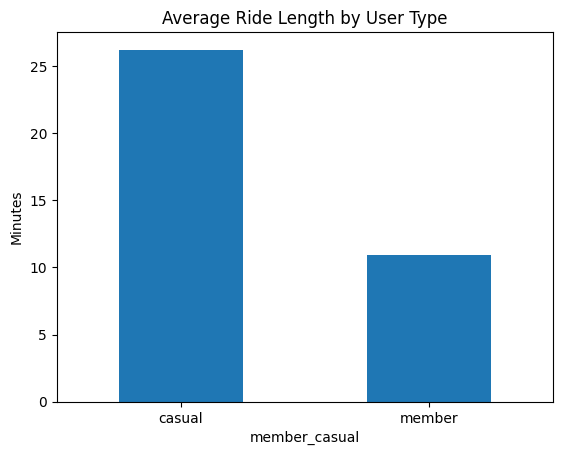

In [41]:
# ============================================================
# STEP 11: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 1. Ride Count Distribution (Market Share)
print("=== Ride Count Distribution (%) ===")
ride_distribution = df['member_casual'].value_counts(normalize=True) * 100
print(ride_distribution)
print("\n")

# 2. Average Ride Length
print("=== Average Ride Length (minutes) ===")
avg_ride_length = df.groupby('member_casual')['ride_length'].mean()
print(avg_ride_length)
print("\n")

# 3. Day of Week Usage
print("=== Usage by Day of Week ===")
day_usage = df.groupby(['day_of_week', 'member_casual']).size().unstack()
print(day_usage)
print("\n")

# Normalize (percentage per user type)
print("=== Day of Week (%) ===")
day_usage_pct = day_usage.div(day_usage.sum(axis=0), axis=1) * 100
print(day_usage_pct)
print("\n")

# 4. Time Period Usage
print("=== Usage by Time Period ===")
time_usage = df.groupby(['time_period', 'member_casual']).size().unstack()
print(time_usage)
print("\n")

print("=== Time Period (%) ===")
time_usage_pct = time_usage.div(time_usage.sum(axis=0), axis=1) * 100
print(time_usage_pct)
print("\n")

# 5. Ride Category Distribution
print("=== Ride Category Distribution ===")
ride_cat = df.groupby(['ride_category', 'member_casual']).size().unstack()
print(ride_cat)
print("\n")

print("=== Ride Category (%) ===")
ride_cat_pct = ride_cat.div(ride_cat.sum(axis=0), axis=1) * 100
print(ride_cat_pct)
print("\n")

# ============================================================
# OPTIONAL VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

avg_ride_length.plot(kind='bar')
plt.title("Average Ride Length by User Type")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.show()

# Step 12: Export Final Clean Dataset

The fully cleaned and processed dataset is exported for use in Excel and Tableau.

This dataset includes:
- Clean ride durations (minutes)
- Standardized user types
- Engineered features (time_period, ride_category, etc.)
- No outliers or invalid records

This file will be used for pivot tables and dashboard creation.

In [42]:
# ============================================================
# FINAL EXPORT: CLEAN DATASET FOR EXCEL & TABLEAU
# ============================================================

# Select only relevant columns (clean structure for analysis)
final_columns = [
    'ride_id',
    'rideable_type',
    'started_at',
    'ended_at',
    'ride_length',
    'day_of_week',
    'hour',
    'month',
    'time_period',
    'ride_category',
    'member_casual',
    'start_station_name',
    'end_station_name'
]

df_final = df[final_columns].copy()

# Export to CSV
df_final.to_csv("Cyclistic_Final_Cleaned.csv", index=False)

print("✅ Export complete: Cyclistic_Final_Cleaned.csv")

✅ Export complete: Cyclistic_Final_Cleaned.csv


### Run to confirm the file location

In [43]:
import os
print(os.getcwd())

D:\OneDrive\Developer\DataAnalytics\Python-Projects
